## 지난주 개념 복습!
아래 마크다운을 풀고, 지난주 예습과제를 통해 공부한 Vision Transformer의 특징과 다른 모델들과의 차이점을 간략히 설명해주세요.

### ViT
- **비전 트랜스 포머 (ViT)** 모델은 트랜스포머 구조 자체를 컴퓨터 비전 분야에 적용한 첫 번째 연구로, 이미지가 격자로 작은 단위의 이미지 패치로 나뉘어 순차적으로 입력되면 이미지 패치가 왼 → 오, 위→ 아래에서 표현된 시퀀선 배열을 가정한다.
- 입력 이미지를 트랜스포머 구조에 맞게 일정한 크기의 패치로 나눈 다음, 각 패치를 벡터 형태로 변환하는 **패치 임베딩(Patch Embedding)**과 각 패치와의 관계를 학습하는 **인코더(Encoder) 계층**으로 이미지 특징을 추출한 이후 분류나 회귀와 같은 작업에 맞는 출력값으로 변환해 사용한다.

### 합성곱 모델
- 이미지 패치 중 일부만 학습하는 **합성곱 모델**과 달리 ViT 모델은 이미지를 작은 패치들로 나눠 각 패치 간의 상관 관계를 학습한다. 이를 위해 셀프 어텐션 방법을 사용해 모든 이미지 패치가 서로에게 주는 영향을 고려해 이미지의 전체 특징을 추출한다.

### 스윈 트랜스포머
- 이미지의 패치 수가 증가하면 학습 데이터의 크기도 커지기 때문에 모델 학습에 필요한 계산량이 증가하는 문제를 해결하기 위해 **스윈 트랜스포머 모델**은 로컬 윈도를 활용해 물체의 크기나 해상도를 계층적으로 학습한다.

### CvT
-  ViT는 이미지를 패치 단위로 분할하고, 이를 트랜스포머 모델의 입력으로 사용하는 방식을 사용해 패치를 겹치치 않게 처리하였지만, **CvT**는 이미지를 처리하기 전에 합성곱 연산으로 특징 맵을 추출한다. 이를 통해 유의미한 패턴을 추출하고 일정한 크기의 패치로 나눠 트랜스포머모델의 입력으로 사용한다. 입력되는 패치들은 겹쳐 학습해서 토큰에 대한 위치 임베딩을 적용하지 않아도 모델의 성능 저하 없이 다양한 해상도를 가진 이미지를 처리할 수 있게 되었다.

## 파이토치로 구현한 Vision Transformer
이번 복습과제에서는 카사바 잎 질병 데이터셋으로 vision transformer를 학습시키겠습니다.
- 첨부된 드라이브에서 필요한 파일들을 다운받을 수 있습니다.

In [1]:
!curl https://raw.githubusercontent.com/pytorch/xla/master/contrib/scripts/env-setup.py -o pytorch-xla-env-setup.py
!python pytorch-xla-env-setup.py --version 1.7
!pip install timm
!pip install torch_xla

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    14  100    14    0     0     74      0 --:--:-- --:--:-- --:--:--    75
  File "/content/pytorch-xla-env-setup.py", line 1
    404: Not Found
    ^^^
SyntaxError: illegal target for annotation
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.0 MB/s eta 0:00:00


### 데이터 불러오기

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
#.zip 파일 unzip
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/Week9/data/train_images.zip -d /content/drive/MyDrive/Week9/data/train_images

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: /content/drive/MyDrive/Week9/data/train_images/train_images/809359953.jpg  
  inflating: /content/drive/MyDrive/Week9/data/train_images/__MACOSX/train_images/._809359953.jpg  
  inflating: /content/drive/MyDrive/Week9/data/train_images/train_images/1892299839.jpg  
  inflating: /content/drive/MyDrive/Week9/data/train_images/__MACOSX/train_images/._1892299839.jpg  
  inflating: /content/drive/MyDrive/Week9/data/train_images/train_images/1446872004.jpg  
  inflating: /content/drive/MyDrive/Week9/data/train_images/__MACOSX/train_images/._1446872004.jpg  
  inflating: /content/drive/MyDrive/Week9/data/train_images/train_images/3035179320.jpg  
  inflating: /content/drive/MyDrive/Week9/data/train_images/__MACOSX/train_images/._3035179320.jpg  
  inflating: /content/drive/MyDrive/Week9/data/train_images/train_images/3624802208.jpg  
  inflating: /content/drive/MyDrive/Week9/data/train_images/__MACOSX/train_images/._3624802208.jpg  
  inflating

In [24]:
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/Week9/jx_vit_base_p16_224-80ecf9dd.pth.zip -d /content/drive/MyDrive/Week9

Archive:  /content/drive/MyDrive/Week9/jx_vit_base_p16_224-80ecf9dd.pth.zip
  inflating: /content/drive/MyDrive/Week9/jx_vit_base_p16_224-80ecf9dd.pth  


In [50]:
#파일 경로
DATA_PATH = "/content/drive/MyDrive/Week9/data"
TRAIN_PATH = "/content/drive/MyDrive/Week9/data/train_images"
TEST_PATH = "/content/drive/MyDrive/Week9/test.jpg"
MODEL_PATH = (
    "/content/drive/MyDrive/Week9/jx_vit_base_p16_224-80ecf9dd.pth"
)

### 라이브러리

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

import torch
import torch.nn as nn
import torchvision.transforms as transforms

import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.distributed.xla_multiprocessing as xmp
import torch_xla.distributed.parallel_loader as pl

import timm

import gc
import os
import time
import random
from datetime import datetime

from PIL import Image
from tqdm.notebook import tqdm
from sklearn import model_selection, metrics

In [27]:
os.environ["XLA_USE_BF16"] = "1"
os.environ["XLA_TENSOR_ALLOCATOR_MAXSIZE"] = "100000000"

In [28]:
def seed_everything(seed):
    """
    Seeds basic parameters for reproductibility of results

    Arguments:
        seed {int} -- Number of the seed
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(1001)

### 파라미터

In [29]:
IMG_SIZE = 224 #ViT에 적합한 이미지 크기로 설정해주세요.
BATCH_SIZE = 16
LR = 2e-05
GAMMA = 0.7
N_EPOCHS = 1  #모델 학습을 위해서는 더 많은 에포크가 필요하지만, 파일 크기가 큰 관계로 이번 과제에서는 전 과정을 한 번만 수행하겠습니다.

In [30]:
# pandas로 csv 파일을 읽은 뒤, 첫 5행을 출력하세요.
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  21397 non-null  object
 1   label     21397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 334.5+ KB


<Axes: xlabel='label'>

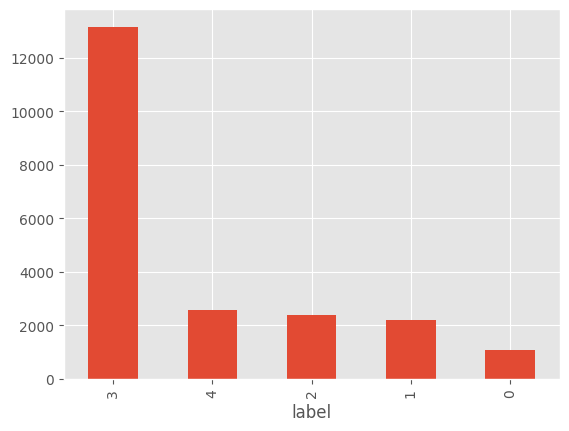

In [32]:
df.label.value_counts().plot(kind="bar")

In [33]:
# train과 test를 9:1로 나눠주세요.
# random_state은 자유롭게 지정 가능합니다.
train_df, valid_df = model_selection.train_test_split(
    df, test_size=0.1, random_state=123, stratify=df.label.values
)

In [51]:
class CassavaDataset(torch.utils.data.Dataset):

    def __init__(self, df, data_path=DATA_PATH, mode="train", transforms=None):
        super().__init__()
        self.df_data = df.values
        self.data_path = data_path
        self.transforms = transforms
        self.mode = mode
        self.data_dir = "train_images" if mode == "train" else "test_images"

    def __len__(self):
        return len(self.df_data)

    def __getitem__(self, index):
        img_name, label = self.df_data[index]
        img_path = os.path.join(self.data_path, self.data_dir, img_name)
        img = Image.open(img_path).convert("RGB")

        if self.transforms is not None:
            image = self.transforms(img)

        return image, label

In [35]:
#데이터 증강
transforms_train = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

transforms_valid = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

In [41]:
#사용 가능한 ViT 모델 목록
##우리는 이중 vit_base_patch16_224를 사용합니다!
print("Available Vision Transformer Models: ")
timm.list_models("vit*")

Available Vision Transformer Models: 


['vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip_gap_512',
 'vit_base_patch16_xp_224',
 'vit_base_patch32_224',
 'vit_base_patch32_384',
 'vit_base_patch32_clip_224',
 'vit_base_patch32_clip_256',
 'vit_base_patch32_clip_384',
 'vit_base_patch32_clip_448',
 'vit_base_patch32

### 모델 설계
- 클래스 ViTBase16의 각 줄을 설명하는 주석을 달아주세요. (최소 15개)

In [42]:
# 이 셀 안의 코드에 대해서 주석을 달아주세요.
class ViTBase16(nn.Module):
    def __init__(self, n_classes, pretrained=False):

        # nn.Module 초기화
        super(ViTBase16, self).__init__()

        # ViT base 모델 생성 (patch 크기 16, 입력 크기 224 * 224)
        self.model = timm.create_model("vit_base_patch16_224", pretrained=False)

        # pretrained model 가중치 불러오기
        if pretrained:
            self.model.load_state_dict(torch.load(MODEL_PATH, weights_only=False))

        self.model.head = nn.Linear(self.model.head.in_features, n_classes)

    # 순전파 정의
    def forward(self, x):
        x = self.model(x)
        return x

    def train_one_epoch(self, train_loader, criterion, optimizer, device):
        epoch_loss = 0.0
        epoch_accuracy = 0.0

        self.model.train() # 모델 학습
        for i, (data, target) in enumerate(train_loader):
            if device.type == "cuda": # cuda -> GPU
                data, target = data.cuda(), target.cuda()

            elif device.type == "xla": # XLA (TPU) 장치일 경우 data와 target 장치로 전송 및 타입 지정
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            optimizer.zero_grad() # gradient 초기화
            output = self.forward(data) # 순전파 학습
            loss = criterion(output, target) # loss 계산
            loss.backward() # 역전파 계산
            accuracy = (output.argmax(dim=1) == target).float().mean() # 정확도 계산

            epoch_loss += loss # 손실 누적
            epoch_accuracy += accuracy # 정확도 누적

            if device.type == "xla": # TPU에서는 optimzer_step 설정
                xm.optimizer_step(optimizer)

                if i % 20 == 0: # Batch 20개마다 출력
                    xm.master_print(f"\tBATCH {i+1}/{len(train_loader)} - LOSS: {loss}")

            else: # CPU/GPU 환경에서는 optimzer.step() 직접 호출
                optimizer.step()

        # 평균 손실 및 정확도 반환
        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader)

    def validate_one_epoch(self, valid_loader, criterion, device):
        valid_loss = 0.0
        valid_accuracy = 0.0

        self.model.eval() # 모델 평가
        for data, target in valid_loader:
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()
            elif device.type == "xla":
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            with torch.no_grad(): # gradient 계산 x
                output = self.model(data)
                loss = criterion(output, target) # loss 계산
                accuracy = (output.argmax(dim=1) == target).float().mean() # 정확도 계산

                valid_loss += loss # loss 누적
                valid_accuracy += accuracy # 정확도 누적
        # 평균 손실 및 정확도 반환
        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)

In [43]:
def fit_tpu(
    model, epochs, device, criterion, optimizer, train_loader, valid_loader=None
):

    valid_loss_min = np.inf

    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    for epoch in range(1, epochs + 1):
        gc.collect()
        para_train_loader = pl.ParallelLoader(train_loader, [device])

        xm.master_print(f"{'='*50}")
        xm.master_print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(
            para_train_loader.per_device_loader(device), criterion, optimizer, device
        )
        xm.master_print(
            f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n"
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        gc.collect()

        if valid_loader is not None:
            gc.collect()
            para_valid_loader = pl.ParallelLoader(valid_loader, [device])
            xm.master_print(f"EPOCH {epoch} - VALIDATING...")
            valid_loss, valid_acc = model.validate_one_epoch(
                para_valid_loader.per_device_loader(device), criterion, device
            )
            xm.master_print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
            valid_losses.append(valid_loss)
            valid_accs.append(valid_acc)
            gc.collect()

            if valid_loss <= valid_loss_min and epoch != 1:
                xm.master_print(
                    "Validation loss decreased ({:.4f} --> {:.4f}).  Saving model ...".format(
                        valid_loss_min, valid_loss
                    )
                )

            valid_loss_min = valid_loss

    return {
        "train_loss": train_losses,
        "valid_losses": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }

In [44]:
model = ViTBase16(n_classes=5, pretrained=True)

In [46]:
def _run():
    train_dataset = CassavaDataset(train_df, transforms=transforms_train)
    valid_dataset = CassavaDataset(valid_df, transforms=transforms_valid)

    train_sampler = torch.utils.data.distributed.DistributedSampler(
        train_dataset,
        num_replicas=xm.xrt_world_size(),
        rank=xm.get_ordinal(),
        shuffle=True,
    )

    valid_sampler = torch.utils.data.distributed.DistributedSampler(
        valid_dataset,
        num_replicas=xm.xrt_world_size(),
        rank=xm.get_ordinal(),
        shuffle=False,
    )

    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        drop_last=True,
        num_workers=8,
    )

    valid_loader = torch.utils.data.DataLoader(
        dataset=valid_dataset,
        batch_size=BATCH_SIZE,
        sampler=valid_sampler,
        drop_last=True,
        num_workers=8,
    )

    criterion = nn.CrossEntropyLoss()  #cross entropy loss로 설정.
    device = xm.xla_device()
    model.to(device)

    lr = LR * xm.xrt_world_size()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    xm.master_print(f"INITIALIZING TRAINING ON {xm.xrt_world_size()} TPU CORES")
    start_time = datetime.now()
    xm.master_print(f"Start Time: {start_time}")

    logs = fit_tpu(
        model=model,
        epochs=N_EPOCHS,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        valid_loader=valid_loader,
    )

    xm.master_print(f"Execution time: {datetime.now() - start_time}")

    xm.master_print("Saving Model")
    xm.save(
        model.state_dict(), f'model_5e_{datetime.now().strftime("%Y%m%d-%H%M")}.pth'
    )

In [ ]:
# Training 시작
def _mp_fn(rank, flags):
    torch.set_default_tensor_type("torch.FloatTensor")
    a = _run()


# Run
FLAGS = {}
xmp.spawn(_mp_fn, args=(FLAGS,), nprocs=1, start_method="fork")

INITIALIZING TRAINING ON 1 TPU CORES
Start Time: 2025-05-12 15:05:58.558122
EPOCH 1 - TRAINING...
	BATCH 1/1203 - LOSS: 1.5859375
	BATCH 21/1203 - LOSS: 1.3984375
	BATCH 41/1203 - LOSS: 1.1953125
	BATCH 61/1203 - LOSS: 1.3515625
	BATCH 81/1203 - LOSS: 1.0546875
	BATCH 101/1203 - LOSS: 1.1796875
	BATCH 121/1203 - LOSS: 1.484375
	BATCH 141/1203 - LOSS: 0.9609375
	BATCH 161/1203 - LOSS: 1.0
	BATCH 181/1203 - LOSS: 0.66015625
	BATCH 201/1203 - LOSS: 1.1640625
	BATCH 221/1203 - LOSS: 0.6796875
	BATCH 241/1203 - LOSS: 1.0859375
	BATCH 261/1203 - LOSS: 1.0078125
	BATCH 281/1203 - LOSS: 1.46875
	BATCH 301/1203 - LOSS: 1.1953125
	BATCH 321/1203 - LOSS: 1.1171875
	BATCH 341/1203 - LOSS: 1.5390625
	BATCH 361/1203 - LOSS: 1.0546875
	BATCH 381/1203 - LOSS: 1.0625
	BATCH 401/1203 - LOSS: 1.0078125
	BATCH 421/1203 - LOSS: 1.359375
	BATCH 441/1203 - LOSS: 1.2578125
	BATCH 461/1203 - LOSS: 1.1328125
	BATCH 481/1203 - LOSS: 0.90625
	BATCH 501/1203 - LOSS: 0.75390625
	BATCH 521/1203 - LOSS: 0.90625
	BATC